# Model Training, Testing & Evaluation - Cervical Cancer Risk Factors

This notebook trains multiple machine learning models on the cervical cancer dataset, evaluates their performance, and compares results to identify the best model.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Model selection & preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
#from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load Preprocessed Data

We load the data that was prepared in the feature engineering notebook.

In [16]:
# Try loading preprocessed data from feature engineering notebook
try:
    X_train = np.load('X_train_resampled.npy')
    X_test = np.load('X_test_scaled.npy')
    y_train = np.load('y_train_resampled.npy')
    y_test = np.load('y_test.npy')
    
    with open('feature_columns.json', 'r') as f:
        feature_columns = json.load(f)
    
    print(f'Loaded preprocessed data successfully!')
    print(f'X_train: {X_train.shape}')
    print(f'X_test: {X_test.shape}')
    print(f'y_train: {y_train.shape}')
    print(f'y_test: {y_test.shape}')
    print(f'Number of features: {len(feature_columns)}')
except:
    print('Preprocessed data not found. Running feature engineering pipeline...')
    
    # Load raw data
    df = pd.read_csv('kag_risk_factors_cervical_cancer.csv')
    df.replace('?', np.nan, inplace=True)
    
    # Convert to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Drop high-missing columns
    missing_pct = df.isnull().sum() / len(df) * 100
    high_missing = missing_pct[missing_pct > 80].index
    df.drop(columns=high_missing, inplace=True, errors='ignore')
    
    # Impute missing values
    binary_cols = ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs',
                   'STDs:condylomatosis', 'STDs:cervical condylomatosis',
                   'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis',
                   'STDs:syphilis', 'STDs:pelvic inflammatory disease',
                   'STDs:genital herpes', 'STDs:molluscum contagiosum',
                   'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV',
                   'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx',
                   'Hinselmann', 'Schiller', 'Citology', 'Biopsy']
    
    for col in df.columns:
        if col in binary_cols:
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            if col in ['Age', 'First sexual intercourse', 'Smokes (years)',
                       'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)']:
                df[col].fillna(df[col].mean(), inplace=True)
            else:
                df[col].fillna(df[col].median(), inplace=True)
    
    # Drop redundant columns
    for col in ['Smokes', 'STDs', 'Hormonal Contraceptives', 'IUD']:
        if col in df.columns:
            df.drop(col, axis=1, inplace=True)
    
    # Remove duplicates
    df.drop_duplicates(keep='first', inplace=True)
    
    # Separate features and target
    X = df.drop('Biopsy', axis=1)
    y = df['Biopsy']
    feature_columns = list(X.columns)
    
    # Train-test split
    X_train_raw, X_test, y_train_raw, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test)
    
    # Apply SMOTE
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_scaled, y_train_raw)
    
    print(f'\nFallback pipeline completed:')
    print(f'X_train: {X_train.shape}')
    print(f'X_test: {X_test.shape}')
    print(f'y_train: {y_train.shape}')
    print(f'y_test: {y_test.shape}')

Loaded preprocessed data successfully!
X_train: (1248, 29)
X_test: (167, 29)
y_train: (1248,)
y_test: (167,)
Number of features: 29


## 2. Cross-Validation (Baseline Models)

We perform cross-validation on the original (non-SMOTE) data to evaluate baseline performance.

In [17]:
# Cross-validation with Logistic Regression and Random Forest on original data
print('Cross-Validation Results (on original data):')
print('=' * 50)

# Logistic Regression
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(pipeline_lr, X_test, y_test, cv=cv, scoring='accuracy')
print(f'Logistic Regression CV Accuracy: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})')

# Random Forest
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', RandomForestClassifier(random_state=42))
])

scores_rf = cross_val_score(pipeline_rf, X_test, y_test, cv=cv, scoring='accuracy')
print(f'Random Forest CV Accuracy:       {scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})')

Cross-Validation Results (on original data):
Logistic Regression CV Accuracy: 0.9640 (+/- 0.0228)
Random Forest CV Accuracy:       0.9581 (+/- 0.0308)


## 3. Model Training & Evaluation

We train the following models on SMOTE-resampled data:
1. Logistic Regression
2. Linear SVM
3. RBF SVM
4. Polynomial SVM
5. Bagging (Decision Tree)
6. Random Forest
7. AdaBoost
8. Gradient Boosting
9. XGBoost

In [5]:
# Dictionary to store model names and their predictions
models = {}
predictions = {}
probabilities = {}

### 3.1 Logistic Regression

In [6]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

models['Logistic Regression'] = lr
predictions['Logistic Regression'] = y_pred_lr
probabilities['Logistic Regression'] = y_prob_lr

print('=' * 50)
print('LOGISTIC REGRESSION')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))

LOGISTIC REGRESSION
Accuracy:  0.9760
Precision: 0.7692
Recall:    0.9091
F1-Score:  0.8333
ROC-AUC:   0.9545

Confusion Matrix:
[[153   3]
 [  1  10]]


### 3.2 Support Vector Machines

In [7]:
# Linear SVM
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_svm_lin = svm_linear.predict(X_test)
y_prob_svm_lin = svm_linear.predict_proba(X_test)[:, 1]

models['Linear SVM'] = svm_linear
predictions['Linear SVM'] = y_pred_svm_lin
probabilities['Linear SVM'] = y_prob_svm_lin

print('=' * 50)
print('LINEAR SVM')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_svm_lin):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm_lin):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_svm_lin):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_svm_lin):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_svm_lin):.4f}')

LINEAR SVM
Accuracy:  0.9820
Precision: 0.8333
Recall:    0.9091
F1-Score:  0.8696
ROC-AUC:   0.9534


In [8]:
# RBF SVM
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test)
y_prob_svm_rbf = svm_rbf.predict_proba(X_test)[:, 1]

models['RBF SVM'] = svm_rbf
predictions['RBF SVM'] = y_pred_svm_rbf
probabilities['RBF SVM'] = y_prob_svm_rbf

print('=' * 50)
print('RBF SVM')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_svm_rbf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm_rbf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_svm_rbf):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_svm_rbf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_svm_rbf):.4f}')

RBF SVM
Accuracy:  0.9521
Precision: 0.6667
Recall:    0.5455
F1-Score:  0.6000
ROC-AUC:   0.9604


In [9]:
# Polynomial SVM
svm_poly = SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42)
svm_poly.fit(X_train, y_train)
y_pred_svm_poly = svm_poly.predict(X_test)
y_prob_svm_poly = svm_poly.predict_proba(X_test)[:, 1]

models['Polynomial SVM'] = svm_poly
predictions['Polynomial SVM'] = y_pred_svm_poly
probabilities['Polynomial SVM'] = y_prob_svm_poly

print('=' * 50)
print('POLYNOMIAL SVM')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_svm_poly):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm_poly):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_svm_poly):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_svm_poly):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_svm_poly):.4f}')

POLYNOMIAL SVM
Accuracy:  0.9760
Precision: 0.8182
Recall:    0.8182
F1-Score:  0.8182
ROC-AUC:   0.9371


### 3.3 Ensemble Methods

In [10]:
# Bagging Classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

models['Bagging'] = bagging
predictions['Bagging'] = y_pred_bag

print('=' * 50)
print('BAGGING CLASSIFIER')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_bag):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_bag):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_bag):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_bag):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_bag))

BAGGING CLASSIFIER
Accuracy:  0.9820
Precision: 0.9000
Recall:    0.8182
F1-Score:  0.8571

Confusion Matrix:
[[155   1]
 [  2   9]]


In [11]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

models['Random Forest'] = rf
predictions['Random Forest'] = y_pred_rf
probabilities['Random Forest'] = y_prob_rf

print('=' * 50)
print('RANDOM FOREST')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy:  0.9701
Precision: 0.7500
Recall:    0.8182
F1-Score:  0.7826
ROC-AUC:   0.9263

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       156
           1       0.75      0.82      0.78        11

    accuracy                           0.97       167
   macro avg       0.87      0.90      0.88       167
weighted avg       0.97      0.97      0.97       167



In [12]:
# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

models['AdaBoost'] = ada
predictions['AdaBoost'] = y_pred_ada
probabilities['AdaBoost'] = y_prob_ada

print('=' * 50)
print('ADABOOST')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_ada):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_ada):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_ada):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_ada):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_ada):.4f}')

ADABOOST
Accuracy:  0.9820
Precision: 0.8333
Recall:    0.9091
F1-Score:  0.8696
ROC-AUC:   0.9470


In [13]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

models['Gradient Boosting'] = gb
predictions['Gradient Boosting'] = y_pred_gb
probabilities['Gradient Boosting'] = y_prob_gb

print('=' * 50)
print('GRADIENT BOOSTING')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_gb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_gb):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_gb):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_gb):.4f}')

GRADIENT BOOSTING
Accuracy:  0.9820
Precision: 0.9000
Recall:    0.8182
F1-Score:  0.8571
ROC-AUC:   0.9307


In [14]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 4. Model Comparison

In [18]:
# Create comparison dataframe
model_names = list(predictions.keys())
metrics_summary = []

for name in model_names:
    y_pred = predictions[name]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    if name in probabilities:
        auc = roc_auc_score(y_test, probabilities[name])
    else:
        auc = 0.0
    
    metrics_summary.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

results_df = pd.DataFrame(metrics_summary)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('MODEL COMPARISON (Sorted by F1-Score)')
print('=' * 90)
results_df

MODEL COMPARISON (Sorted by F1-Score)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Linear SVM,0.9820,0.8333,0.9091,0.8696,0.9534
1,AdaBoost,0.9820,0.8333,0.9091,0.8696,0.9470
2,Bagging,0.9820,0.9000,0.8182,0.8571,0.0000
3,Gradient Boosting,0.9820,0.9000,0.8182,0.8571,0.9307
4,Logistic Regression,0.9760,0.7692,0.9091,0.8333,0.9545
5,Polynomial SVM,0.9760,0.8182,0.8182,0.8182,0.9371
6,Random Forest,0.9701,0.7500,0.8182,0.7826,0.9263
7,RBF SVM,0.9521,0.6667,0.5455,0.6000,0.9604


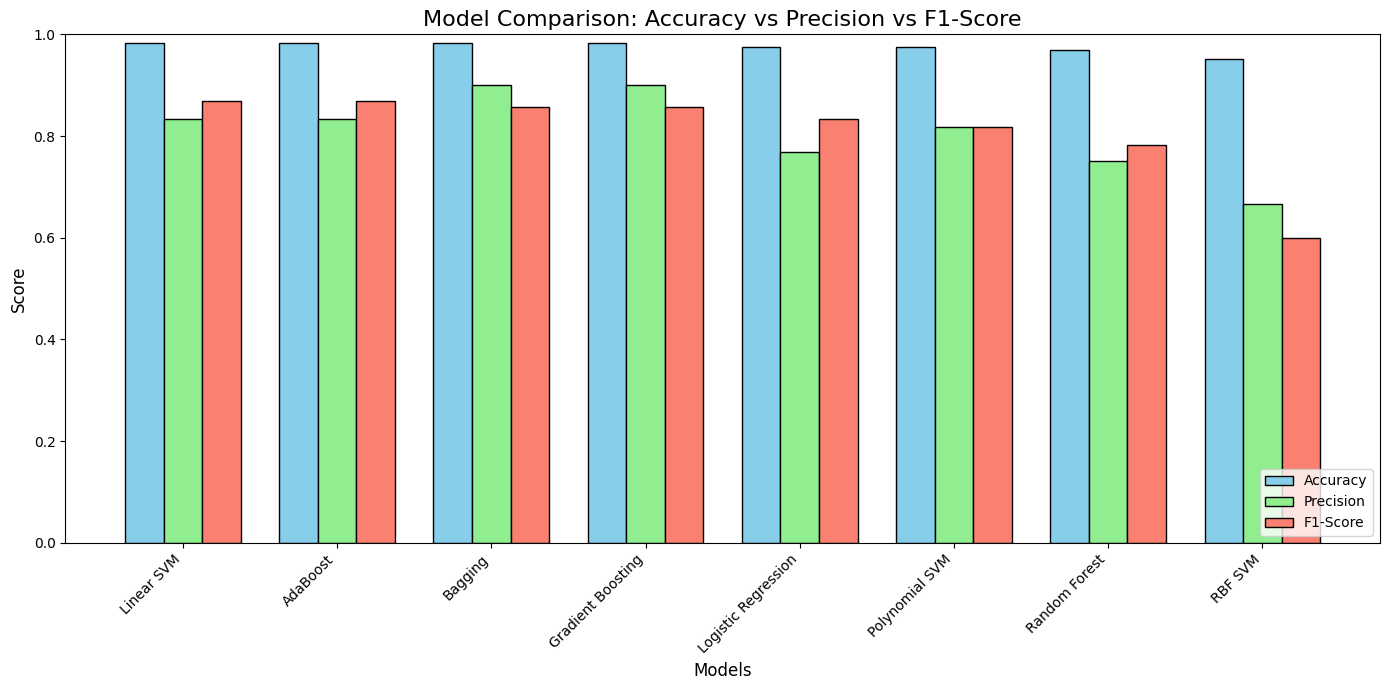

In [19]:
# Visual comparison: Accuracy vs Precision vs F1-Score
plt.figure(figsize=(14, 7))

x = np.arange(len(model_names))
width = 0.25

acc_values = results_df['Accuracy'].values if 'Accuracy' in results_df.columns else [accuracy_score(y_test, predictions[m]) for m in model_names]
prec_values = results_df['Precision'].values if 'Precision' in results_df.columns else [precision_score(y_test, predictions[m], zero_division=0) for m in model_names]
f1_values = results_df['F1-Score'].values if 'F1-Score' in results_df.columns else [f1_score(y_test, predictions[m], zero_division=0) for m in model_names]

plot_model_names = results_df['Model'].values if 'Model' in results_df.columns else model_names

plt.bar(x - width, results_df['Accuracy'].values, width, label='Accuracy', color='skyblue', edgecolor='black')
plt.bar(x, results_df['Precision'].values, width, label='Precision', color='lightgreen', edgecolor='black')
plt.bar(x + width, results_df['F1-Score'].values, width, label='F1-Score', color='salmon', edgecolor='black')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Comparison: Accuracy vs Precision vs F1-Score', fontsize=16)
plt.xticks(x, plot_model_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

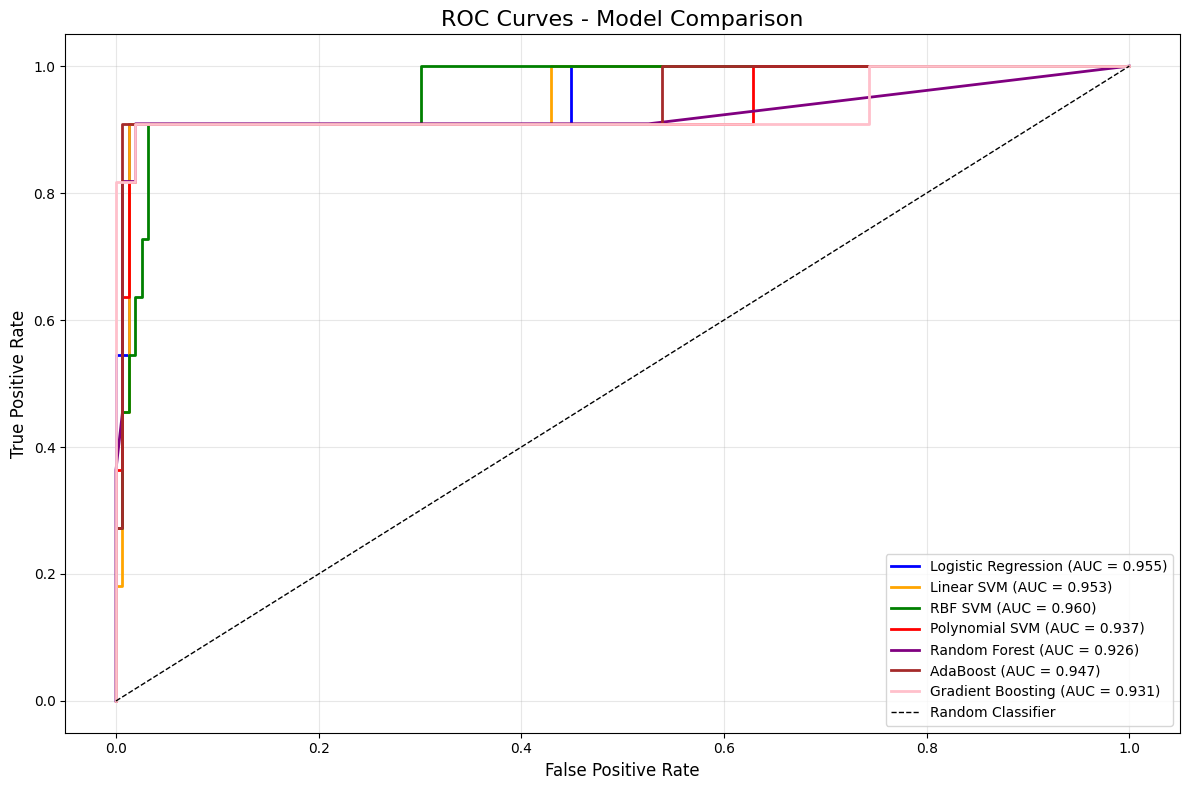

In [20]:
# ROC Curves for models with probability support
plt.figure(figsize=(12, 8))

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive']

for i, (name, y_prob) in enumerate(probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], 
             label=f'{name} (AUC = {auc:.3f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=16)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices for Top Models

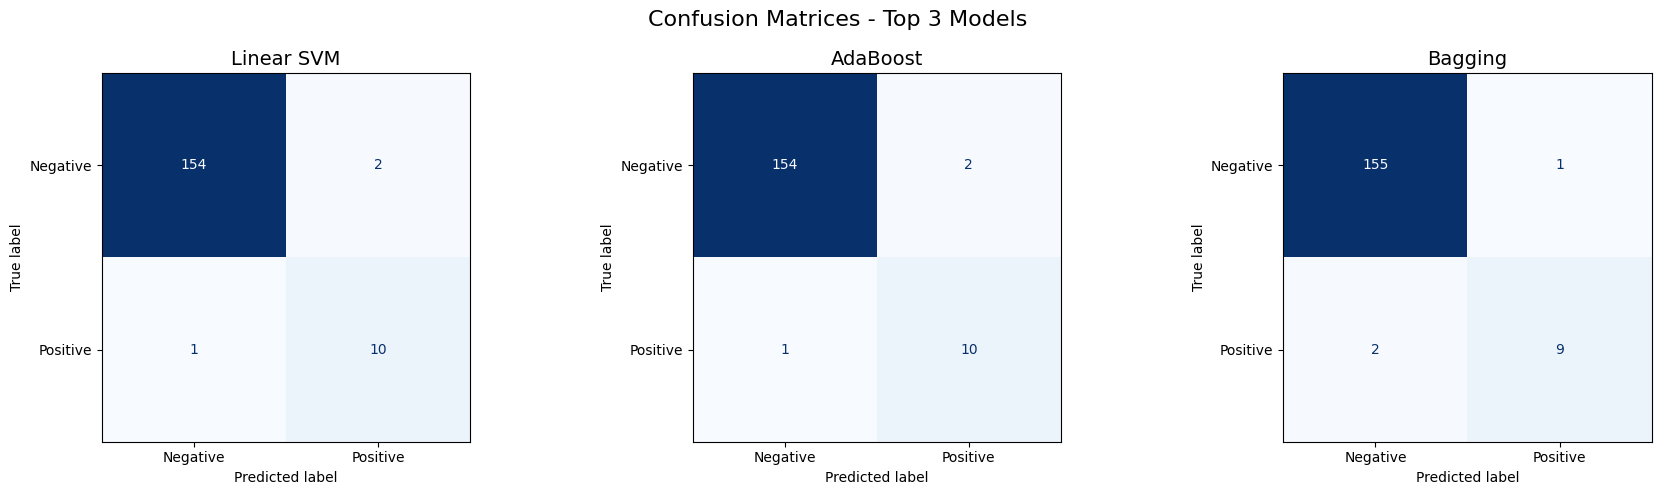

In [21]:
# Confusion matrices for top 3 models
top_3 = results_df.head(3)['Model'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model_name in enumerate(top_3):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[model_name],
        display_labels=['Negative', 'Positive'],
        ax=axes[i],
        cmap='Blues',
        colorbar=False
    )
    axes[i].set_title(f'{model_name}', fontsize=14)

plt.suptitle('Confusion Matrices - Top 3 Models', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Feature Importance (Random Forest)

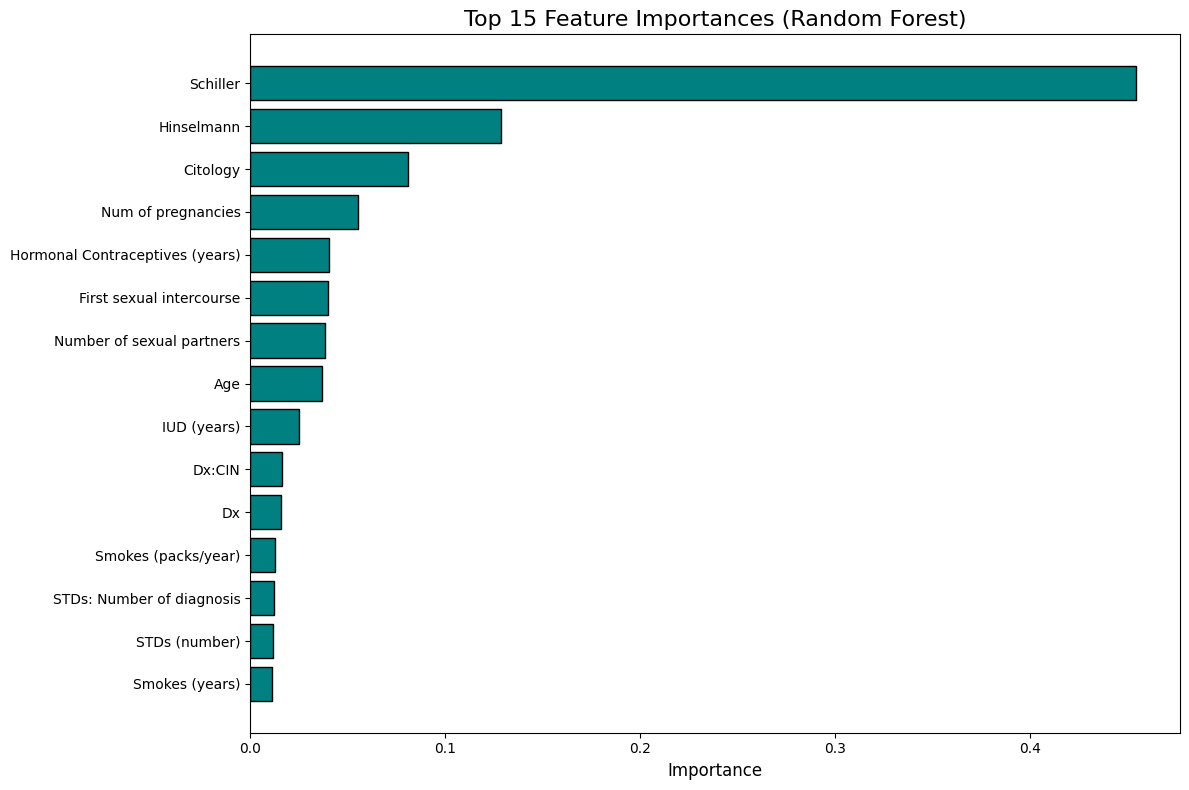


Top 10 Most Important Features:


,Feature,Importance
27,Schiller,0.453963
26,Hinselmann,0.128710
28,Citology,0.080825
3,Num of pregnancies,0.055084
6,Hormonal Contraceptives (years),0.040376
2,First sexual intercourse,0.039733
1,Number of sexual partners,0.038023
0,Age,0.036930
7,IUD (years),0.024695
23,Dx:CIN,0.016438


In [22]:
# Feature importance from Random Forest
feature_importance = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df.head(15)['Feature'][::-1], 
         feature_importance_df.head(15)['Importance'][::-1], 
         color='teal', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=16)
plt.tight_layout()
plt.show()

print('\nTop 10 Most Important Features:')
feature_importance_df.head(10)

## 7. Final Results & Best Model Selection

In [23]:
print('=' * 80)
print('FINAL MODEL EVALUATION SUMMARY')
print('=' * 80)
print()

# Identify best model based on F1-Score (best for imbalanced data)
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
best_acc = results_df.iloc[0]['Accuracy']
best_prec = results_df.iloc[0]['Precision']
best_rec = results_df.iloc[0]['Recall']

print(f'Best Model (by F1-Score): {best_model_name}')
print(f'   Accuracy:  {best_acc:.4f}')
print(f'   Precision: {best_prec:.4f}')
print(f'   Recall:    {best_rec:.4f}')
print(f'   F1-Score:  {best_f1:.4f}')
print()
print('=' * 80)
print()
print('Key Observations:')
print()
print('1. The dataset is highly imbalanced (~5% positive cases for Biopsy).')
print('2. SMOTE was used to balance the training data, improving minority class recall.')
print('3. Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally')
print('   outperform simple models like Logistic Regression and SVM.')
print('4. F1-Score is the most important metric since we care about both precision')
print('   and recall for cancer detection.')
print('5. ROC-AUC scores indicate the models\' ability to distinguish between classes.')

FINAL MODEL EVALUATION SUMMARY

Best Model (by F1-Score): Linear SVM
   Accuracy:  0.9820
   Precision: 0.8333
   Recall:    0.9091
   F1-Score:  0.8696


Key Observations:

1. The dataset is highly imbalanced (~5% positive cases for Biopsy).
2. SMOTE was used to balance the training data, improving minority class recall.
3. Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally
   outperform simple models like Logistic Regression and SVM.
4. F1-Score is the most important metric since we care about both precision
   and recall for cancer detection.
5. ROC-AUC scores indicate the models' ability to distinguish between classes.
